In [1]:
%matplotlib inline
import os
import json
import time
import requests
import datetime
import dateutil
import pandas as pd
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from urllib.request import urlopen
import json
import plotly.express as px
sns.set()

#### Event-based Contagion Forecasting
The following analysis seeks to determine if there is a correlation between the information on Covid-19, number of Covid-19 cases and the number of attributed deaths in relation to the timing and location of Trump's 2020 campaign rallies for U.S. President.  The analysis assumes that the covid statistics will be captured for each city in which a rally occured. The rally schedule ('https://ballotpedia.org/Donald_Trump_presidential_campaign,_2020#Campaign_rallies') is listed by city and New York Times Covid-19 data ('https://raw.githubusercontent.com/nytimes/covid-19-data/master/us-counties.csv') is by county, therefore the table is joined first by looking up the county for each city, and getting the fips coded geographic boundaries:

In [2]:
cities=pd.read_csv('https://raw.githubusercontent.com/kelvins/US-Cities-Database/main/csv/us_cities.csv'
                  ).drop('STATE_CODE',axis=1)
cities.columns=[i.lower().split('_')[0] for i in cities.columns]

In [3]:
with urlopen('https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json') as response:
    counties = json.load(response)
    
county_coordinates=pd.DataFrame([(item['id'],item['geometry']['coordinates'][0][0]) 
                          for item in counties['features']],columns=['fips','coord'])

Covid-19 dataset is downloaded to a dataframe:

In [4]:
covid=pd.read_csv('https://raw.githubusercontent.com/nytimes/covid-19-data/master/us-counties.csv',
                  parse_dates=['date'],dtype={"fips": str}).set_index("date")
covid['county_state']=covid.county+'_'+covid.state
print("The complete Covid-19 dataset has {} records".format(covid.shape[0]))
covid.tail()

The complete Covid-19 dataset has 2502832 records


,county,state,fips,cases,deaths,county_state
date,,,,,,
2022-05-13,Sweetwater,Wyoming,56037,11088,126.0,Sweetwater_Wyoming
2022-05-13,Teton,Wyoming,56039,10074,16.0,Teton_Wyoming
2022-05-13,Uinta,Wyoming,56041,5643,39.0,Uinta_Wyoming
2022-05-13,Washakie,Wyoming,56043,2358,44.0,Washakie_Wyoming
2022-05-13,Weston,Wyoming,56045,1588,18.0,Weston_Wyoming


In [5]:
# Rally data reconstructed from Ballotpedia source:
# https://ballotpedia.org/Donald_Trump_presidential_campaign,_2020#Campaign_rallies
# Original file was read from a local Excel file that is no longer available.

rally_data = [
    # COVID-era rallies (post March 13, 2020) — indices 0-20
    ('2020-11-01', 'Opa-locka', 'Florida'),        # 0
    ('2020-10-21', 'Gastonia', 'North Carolina'),   # 1
    ('2020-10-20', 'Erie', 'Pennsylvania'),         # 2
    ('2020-10-14', 'Des Moines', 'Iowa'),           # 3
    ('2020-10-12', 'Sanford', 'Florida'),           # 4
    ('2020-09-21', 'Swanton', 'Ohio'),              # 5 -> Fulton
    ('2020-09-30', 'Duluth', 'Minnesota'),          # 6
    ('2020-09-18', 'Bemidji', 'Minnesota'),         # 7 -> Beltrami
    ('2020-09-17', 'Mosinee', 'Wisconsin'),         # 8 -> Marathon
    ('2020-09-13', 'Henderson', 'Nevada'),          # 9
    ('2020-09-10', 'Freeland', 'Michigan'),         # 10
    ('2020-09-08', 'Winston-Salem', 'North Carolina'),  # 11
    ('2020-09-24', 'Jacksonville', 'Florida'),      # 12
    ('2020-09-19', 'Fayetteville', 'North Carolina'),   # 13
    ('2020-08-28', 'Londonderry', 'New Hampshire'),     # 14
    ('2020-08-20', 'Scranton', 'Pennsylvania'),     # 15 -> Lackawanna
    ('2020-09-03', 'Latrobe', 'Pennsylvania'),      # 16
    ('2020-10-29', 'Tampa', 'Florida'),             # 17
    ('2020-10-26', 'Lititz', 'Pennsylvania'),       # 18
    ('2020-06-23', 'Phoenix', 'Arizona'),           # 19
    ('2020-06-20', 'Tulsa', 'Oklahoma'),            # 20 -> Creek/Tulsa
    # Pre-COVID rallies — indices 21+
    ('2020-03-02', 'Charlotte', 'North Carolina'),
    ('2020-02-28', 'North Charleston', 'South Carolina'),
    ('2020-02-20', 'Colorado Springs', 'Colorado'),
    ('2020-02-19', 'Phoenix', 'Arizona'),
    ('2020-02-10', 'Manchester', 'New Hampshire'),
    ('2020-01-14', 'Milwaukee', 'Wisconsin'),
    ('2020-01-30', 'Des Moines', 'Iowa'),
    ('2020-01-28', 'Wildwood', 'New Jersey'),
    ('2020-01-09', 'Toledo', 'Ohio'),
    ('2019-11-26', 'Sunrise', 'Florida'),
    ('2019-12-18', 'Battle Creek', 'Michigan'),
]

rallies = pd.DataFrame(rally_data, columns=['date', 'city', 'state'])
rallies['date'] = pd.to_datetime(rallies['date'])

covid_era = [1 for i in range(rallies[rallies.date > pd.Timestamp('2020-03-13')].shape[0])] + \
            [0 for i in range(rallies[rallies.date < pd.Timestamp('2020-03-13')].shape[0])]
rallies['covid_era'] = covid_era
print('Trump campaign has conducted {} campaign rallies since March 13, 2020'.format(
    rallies[rallies.date > pd.Timestamp('2020-03-13')].shape[0]))
print("{} percent of Trump's rallies have taken place during the pandemic.".format(
    rallies['covid_era'].sum() / rallies['covid_era'].count() * 100))

Trump campaign has conducted 21 campaign rallies since March 13, 2020
65.625 percent of Trump's rallies have taken place during the pandemic.


For every rally city find the county the city is in.

In [6]:
lst=[]
for d,rc,rs in zip(rallies.date,rallies.city,rallies.state):
    try:
        lst.append((d,rc,cities[(cities.city==rc)& (cities.state==rs)]['county'].values[0],rs))
    except:
        lst.append((d,rc,'Check',rs))

In [7]:
rallies_w_county=pd.DataFrame(lst,columns=['date','city','county','state'])
# Fix counties not found in US Cities DB
rallies_w_county.at[3,'county']='Polk'           # Des Moines, Iowa
rallies_w_county.at[17,'county']='Hillsborough'  # Tampa, Florida
rallies_w_county.at[27,'county']='Polk'           # Des Moines, Iowa (pre-covid)
rallies_w_county['county_state']=rallies_w_county.county+'_'+rallies_w_county.state
rallies_w_county.county_state=rallies_w_county.county_state.replace('Saint Louis_Minnesota', 'St. Louis_Minnesota')
rallies_w_county.county_state=rallies_w_county.county_state.replace('Check_Florida', 'Broward_Florida')
rallies_w_county.county_state=rallies_w_county.county_state.replace('Check_North Carolina', 'Forsyth_North Carolina')
rallies_w_county.county_state=rallies_w_county.county_state.replace('Miami-dade_Florida', 'Miami-Dade_Flordia')
rallies_w_county.head()

,date,city,county,state,county_state
0,2020-11-01,Opa-locka,Check,Florida,Broward_Florida
1,2020-10-21,Gastonia,Gaston,North Carolina,Gaston_North Carolina
2,2020-10-20,Erie,Erie,Pennsylvania,Erie_Pennsylvania
3,2020-10-14,Des Moines,Polk,Iowa,Polk_Iowa
4,2020-10-12,Sanford,Seminole,Florida,Seminole_Florida


 Merge with trump rallies dataset and then **save** it.

We'll calculate basic statistics for the entire covid dataset...

In [8]:
ROLLING_MEAN_WINDOW=5
start_date='2020-02-01'

# Filter to post start_date
df = covid[covid.index > start_date].copy()

# Vectorized: compute new_cases, new_deaths, pct_change per county_state using groupby
df['new_cases'] = df.groupby('county_state')['cases'].diff()
df['new_deaths'] = df.groupby('county_state')['deaths'].diff()
df['cases_pct_change'] = df.groupby('county_state')['cases'].pct_change(periods=ROLLING_MEAN_WINDOW)
df['deaths_pct_change'] = df.groupby('county_state')['deaths'].pct_change(periods=ROLLING_MEAN_WINDOW)

# Mark rally counties
rally_counties = set(rallies_w_county.county_state)
df['y_county'] = df['county_state'].apply(lambda x: 'y' if x in rally_counties else 'n')
df['y_count'] = (df['y_county'] == 'y').astype(int)

df.to_pickle('trump.pkl')

**load data** from saved copy we don't have to rerun processing

In [9]:
df=pd.read_pickle('trump.pkl')
df.sample(5)

,county,state,fips,cases,deaths,county_state,new_cases,new_deaths,cases_pct_change,deaths_pct_change,y_county,y_count
date,,,,,,,,,,,,
2020-09-02,Unknown,Michigan,NaN,461,5.0,Unknown_Michigan,2.0,0.0,0.336232,0.250000,n,0
2021-09-30,Windham,Connecticut,09015,12482,208.0,Windham_Connecticut,-1.0,0.0,0.012410,0.040000,n,0
2022-01-18,Otsego,Michigan,26137,4835,88.0,Otsego_Michigan,51.0,0.0,0.052689,0.023256,n,0
2021-08-19,Posey,Indiana,18129,3078,37.0,Posey_Indiana,20.0,0.0,0.026342,0.027778,n,0
2021-05-22,Decatur,Iowa,19053,609,9.0,Decatur_Iowa,0.0,0.0,0.001645,0.000000,n,0


#### Inspecting the data

In [10]:
#all_states_only=df.replace([np.inf, -np.inf], np.nan).groupby(['state_x','fips'])[['cases_pct_change']].mean().reset_index()
df=df.replace([np.inf, -np.inf], np.nan)
df.describe()

,cases,deaths,new_cases,new_deaths,cases_pct_change,deaths_pct_change,y_count
count,2.502786e+06,2.445181e+06,2.499509e+06,2.441982e+06,2.483840e+06,2.166570e+06,2.502786e+06
mean,1.003399e+04,1.616131e+02,3.295900e+01,4.092459e-01,5.648373e-01,4.160909e-02,9.159393e-03
std,4.752563e+04,8.203409e+02,6.309677e+02,9.554141e+00,1.588807e+02,3.239826e-01,9.526543e-02
min,0.000000e+00,0.000000e+00,-3.702510e+05,-1.131700e+04,-1.000000e+00,-1.000000e+00,0.000000e+00
25%,3.820000e+02,6.000000e+00,0.000000e+00,0.000000e+00,3.043195e-03,0.000000e+00,0.000000e+00
50%,1.773000e+03,3.300000e+01,2.000000e+00,0.000000e+00,1.456816e-02,0.000000e+00,0.000000e+00
75%,5.885000e+03,1.010000e+02,1.300000e+01,0.000000e+00,4.936366e-02,1.970443e-02,0.000000e+00
max,2.908425e+06,4.026700e+04,1.937860e+05,1.554000e+03,1.128935e+05,2.160000e+02,1.000000e+00


In [11]:
#df.groupby(['state_x','date'])[['cases_pct_change']].mean().reset_index().plot()
states=df.groupby('state')[['new_cases','cases_pct_change']].agg({'cases_pct_change': ['min', 'max', 'mean'], 'new_cases': ['sum']})
states.sort_values(('cases_pct_change','max'),ascending=False)

cases_pct_change                            new_cases
                                      min            max       mean        sum
state                                                                         
Florida                         -1.000000  112893.500000  19.933293  5997918.0
California                      -0.829564   33080.000000   2.948896  9357034.0
Missouri                        -0.980392    3893.500000   0.115845  1461412.0
Virginia                        -1.000000    2723.000000   0.103908  1733169.0
Washington                      -0.991416    1631.500000   0.344720  1534203.0
Iowa                            -1.000000     799.250000   0.235247   768757.0
Idaho                           -0.500000     767.250000   0.098740   451035.0
New Jersey                      -0.830149     644.000000   0.228658  2313030.0
North Dakota                    -1.000000     390.000000   0.071511   242395.0
Oklahoma                        -0.972826     183.857143   0.088954  1044089.0
New Mexico                      -1.000000     179.000000   0.096844   526093.0
Colorado                        -0.761194     135.000000   0.075327  1412125.0
Mississippi                     -0.842520     126.000000   0.070692   801419.0
Northern Mariana Islands        -0.996271      68.000000   0.323529    11259.0
Tennessee                       -1.000000      64.000000   0.087182  1990817.0
Illinois                        -1.000000      56.000000   0.077369  3214844.0
Nebraska                        -1.000000      49.666667   0.067119   482182.0
Minnesota                       -1.000000      49.500000   0.073233  1479239.0
Louisiana                       -0.975209      47.101302   0.090445  1244331.0
New York                        -0.500000      46.000000   0.099897  5267295.0
Michigan                        -1.000000      45.000000   0.085197  2472487.0
Massachusetts                   -0.697248      40.000000   0.133228  1809292.0
North Carolina                  -0.500000      39.000000   0.077485  2693478.0
Maine                           -0.970588      37.250000   0.124225   254410.0
New Hampshire                   -1.000000      33.000000   0.088121   316676.0
Arkansas                        -0.904762      33.000000   0.076060   838143.0
South Carolina                  -0.166667      30.000000   0.081136  1481589.0
Kentucky                        -1.000000      30.000000   0.070817  1345671.0
Texas                           -0.781897      29.000000   0.071655  6796132.0
Oregon                          -0.666667      29.000000   0.077656   740302.0
Pennsylvania                    -0.500000      26.000000   0.089525  2850275.0
Georgia                         -0.889070      24.666667   0.072012  2460619.0
Alabama                         -0.333333      23.000000   0.075525  1304627.0
Connecticut                     -0.555556      23.000000   0.099190   779273.0
West Virginia                   -0.555556      23.000000   0.067911   505458.0
Wisconsin                       -1.000000      22.500000   0.071775  1637272.0
Ohio                            -1.000000      21.000000   0.080057  2723932.0
Utah                            -1.000000      19.250000   0.074456   939046.0
Nevada                          -1.000000      18.214286   0.073915   724901.0
Montana                         -0.666667      18.000000   0.062640   275371.0
Maryland                        -1.000000      18.000000   0.088712  1052141.0
Arizona                         -0.894737      18.000000   0.096123  2030923.0
Indiana                         -1.000000      17.000000   0.077533  1713723.0
Kansas                          -0.500000      16.000000   0.066604   781618.0
Alaska                          -0.846154      15.000000   0.072155   254435.0
Vermont                         -0.939729      14.325581   0.071650   128425.0
South Dakota                    -0.666667      14.000000   0.061128   238618.0
Delaware                        -0.903226      11.000000   0.095205   26725

#### Distribution of All States. The mean pct change for all states during the period.

50.54 percent


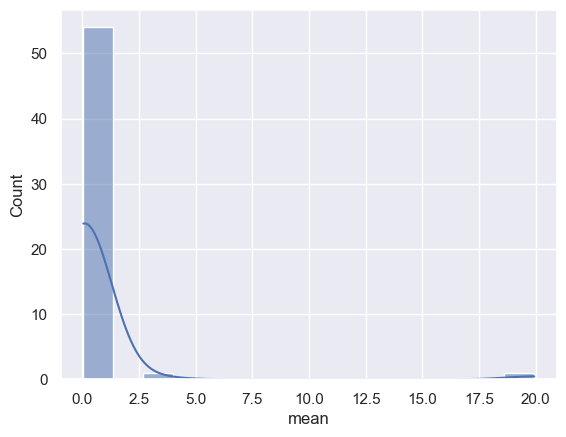

In [12]:
stat=states['cases_pct_change']
sns.histplot(stat['mean'], kde=True)
print('{:.02f} percent'.format(stat['mean'].mean()*100))

#### States experiencing the biggest average increase in cases since March 13, 2020

In [13]:
stat.sort_values('mean', ascending=False).head(10)

,min,max,mean
state,,,
Florida,-1.000000,112893.500000,19.933293
California,-0.829564,33080.000000,2.948896
Washington,-0.991416,1631.500000,0.344720
Northern Mariana Islands,-0.996271,68.000000,0.323529
American Samoa,0.000000,2.166667,0.274138
Iowa,-1.000000,799.250000,0.235247
New Jersey,-0.830149,644.000000,0.228658
Massachusetts,-0.697248,40.000000,0.133228
Maine,-0.970588,37.250000,0.124225


#### States experiencing lowest average increase since March 13, 2020.

In [14]:
stat.sort_values('mean', ascending=False).tail(10)

,min,max,mean
state,,,
Kentucky,-1.000000,30.000000,0.070817
Mississippi,-0.842520,126.000000,0.070692
West Virginia,-0.555556,23.000000,0.067911
Nebraska,-1.000000,49.666667,0.067119
Kansas,-0.500000,16.000000,0.066604
Wyoming,-0.500000,8.000000,0.066556
Montana,-0.666667,18.000000,0.062640
South Dakota,-0.666667,14.000000,0.061128
Virgin Islands,-1.000000,7.500000,0.051743


#### Trump Rallies Since March 13, 2020

In [15]:
sns.set()
def filter_features(df,source_column,target_item_list):
    return df[df[source_column].isin(target_item_list)]

def filter_time(df,target_date,time_window,look_forward):
    if look_forward:
        delta= target_date+pd.Timedelta(days=time_window)
        tmp=df[(df.index > target_date) & (df.index < delta)]
    else:
        delta= target_date-pd.Timedelta(days=time_window)
        tmp=df[(df.index > delta) & (df.index < target_date)]
    return tmp

def plot_effect(rally,rally_date,show_off,stat):
    """rallies_w_county.county[0]"""
    plt.figure(figsize=(15,4))

    ax=sns.lineplot(data=rally.new_cases, color="y",linewidth = 3);
    ax2 = ax.twinx()
    ax2.bar(rally.index,rally.new_deaths,color='red',alpha=.2)

    ax.set_ylabel('cases',color="y",fontsize=16)
    ax2.set_ylabel('deaths',color="red",fontsize=14)
    
    offset = pd.Timedelta(show_off, 'D')
    
    plt.title('Trump Effect in {} | daily avg. incr. in cases: {:.02f} percent'.format(rally.county_state.iloc[0], stat*100))
    #ax.legend(['input'], loc=2)

    ax.axvline(rally_date + offset, alpha=0.3, color='black')
    ax.axvline(rally_date, alpha=0.9, color='red', linewidth=2.5)
    ax.axvline(rally_date - offset, alpha=0.3, color='black')
    ymark=rally.new_cases.max()
    ax.text(x=rally_date, y=int(ymark*.6), s='Trump Rally \n{:%Y-%m-%d}'.format(rally_date), color='r',fontsize=15)
    ax.text(x=rally_date+offset, y=int(ymark*.4), s='{} Days After'.format(show_off), alpha=.5, color='b')
    ax.text(x=rally_date-offset, y=int(ymark*.4), s='{} Days Before'.format(show_off), alpha=.5, color='b')
    
    return plt

In [16]:
TIME_WINDOW=20

def trump_rally_effect(select,stat=False,plot=False,verbose=False):    
    selection=list(rallies_w_county[['date','county_state']].iloc[select])
    selected_county_state=filter_features(df,'county_state',[selection[1]])
    look_forward=filter_time(selected_county_state,selection[0],TIME_WINDOW,True)
    look_backward=filter_time(selected_county_state,selection[0],TIME_WINDOW,False)
    look_span=pd.concat([look_backward, look_forward])
    backward_span=filter_time(selected_county_state,selection[0],20,False)
    view_span=pd.concat([backward_span, look_forward])
    stat=(look_forward.new_cases.mean()-look_backward.new_cases.mean())/look_backward.new_cases.mean()
    if plot:
        plot_effect(rally=view_span,rally_date=selection[0],show_off=20,stat=stat)
    if verbose:
        print('county_state of selected rally: {}'.format(selection[1]))
        print('date of selected rally: {:%Y-%m-%d}'.format(selection[0]))
        print('the average number of new cases per day increased by: {:.02f} percent'.format(stat*100))
    if stat:
        stat_=[stat, selection[0], selection[1]]
    else:
        stat_=None
    return stat_

#### Trump Rallies with by mean percentage daily increase

In [17]:
lst=[]
for i in range(21):
    lst.append([i]+trump_rally_effect(i,stat=True))
tmp=pd.DataFrame(lst, columns=['idx','mean_pct_daily_increase','date','county_state']).set_index('idx')
tmp['mean_pct_daily_increase']=np.round(tmp.mean_pct_daily_increase*100,2)
tmp=tmp.sort_values(by='mean_pct_daily_increase',ascending=False)
tmp

,mean_pct_daily_increase,date,county_state
idx,,,
7,370.45,2020-09-18,Beltrami_Minnesota
8,354.96,2020-09-17,Marathon_Wisconsin
5,248.94,2020-09-21,Fulton_Ohio
15,209.21,2020-08-20,Lackawanna_Pennsylvania
20,192.59,2020-06-20,Creek_Oklahoma
18,138.21,2020-10-26,Lancaster_Pennsylvania
19,124.77,2020-06-23,Maricopa_Arizona
2,123.40,2020-10-20,Erie_Pennsylvania
3,107.81,2020-10-14,Polk_Iowa


#### Impact of Trump Rallies | per pct increase in daily avg of cases 

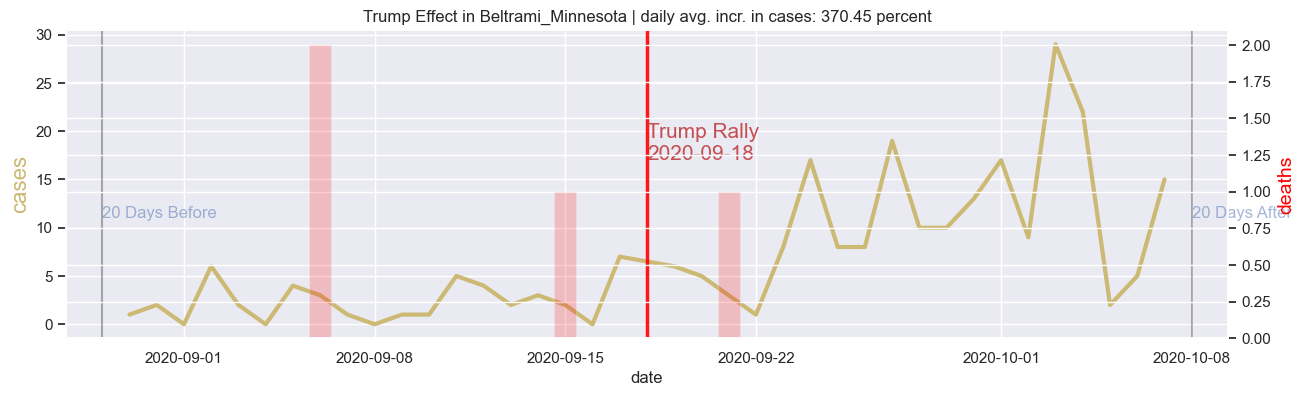

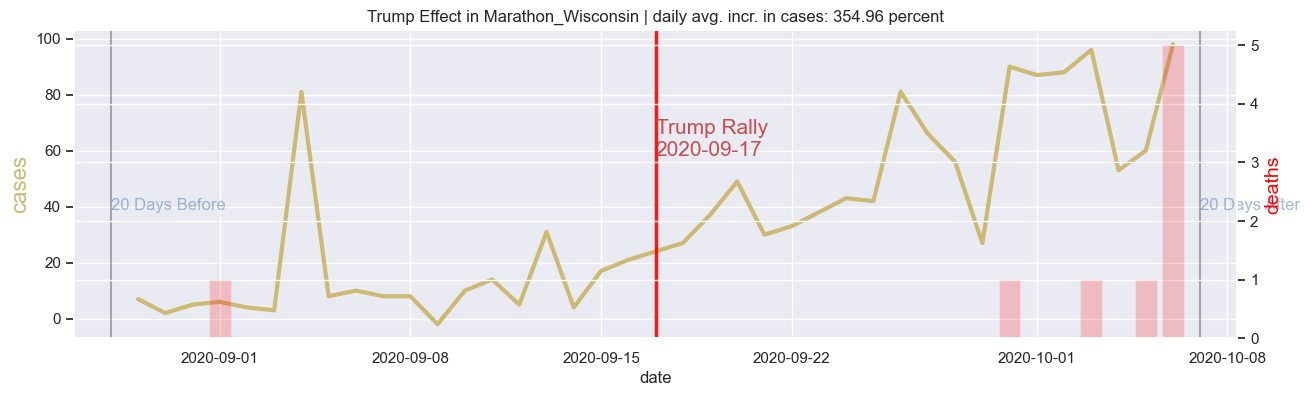

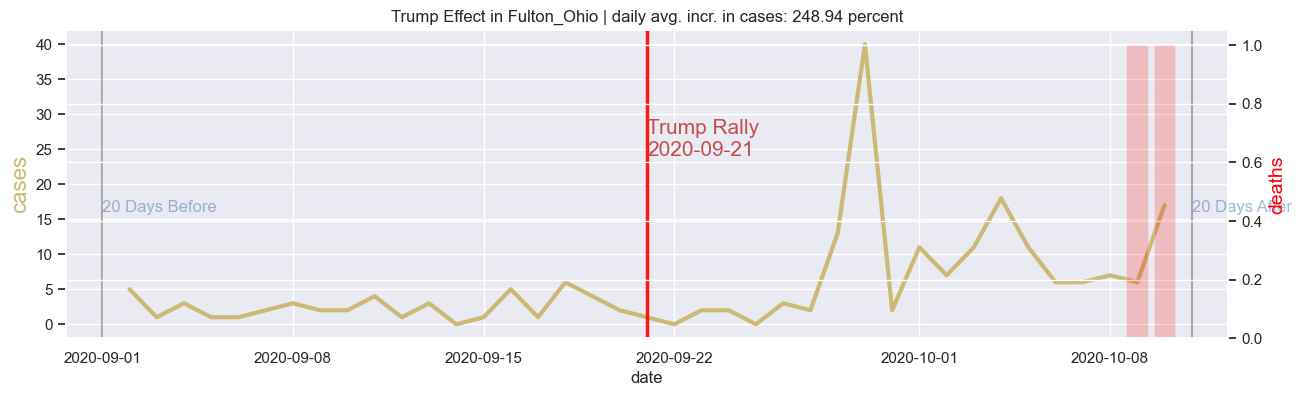

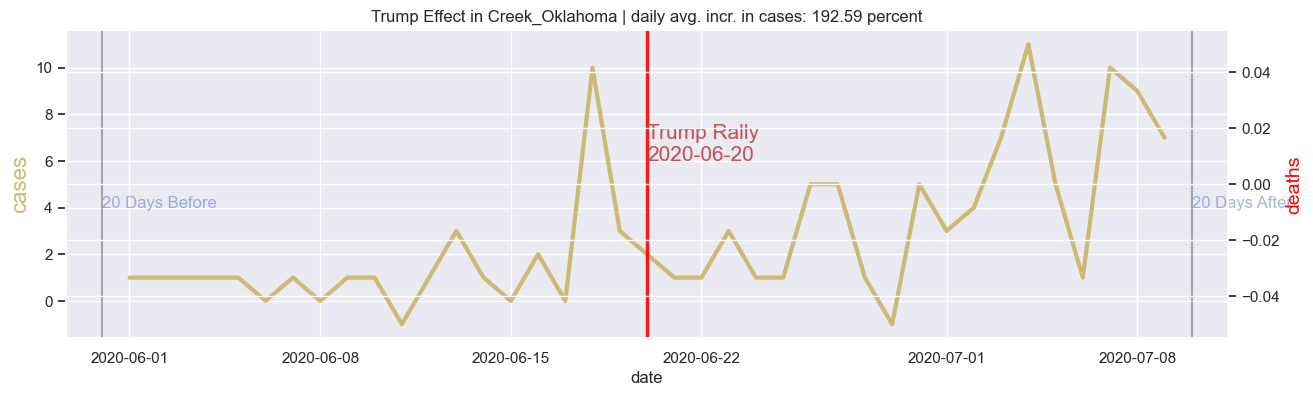

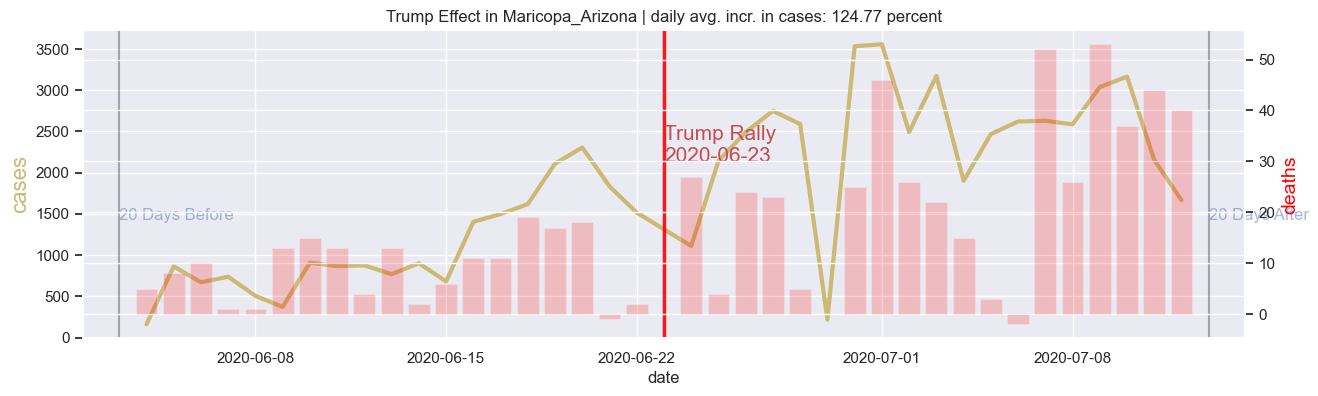

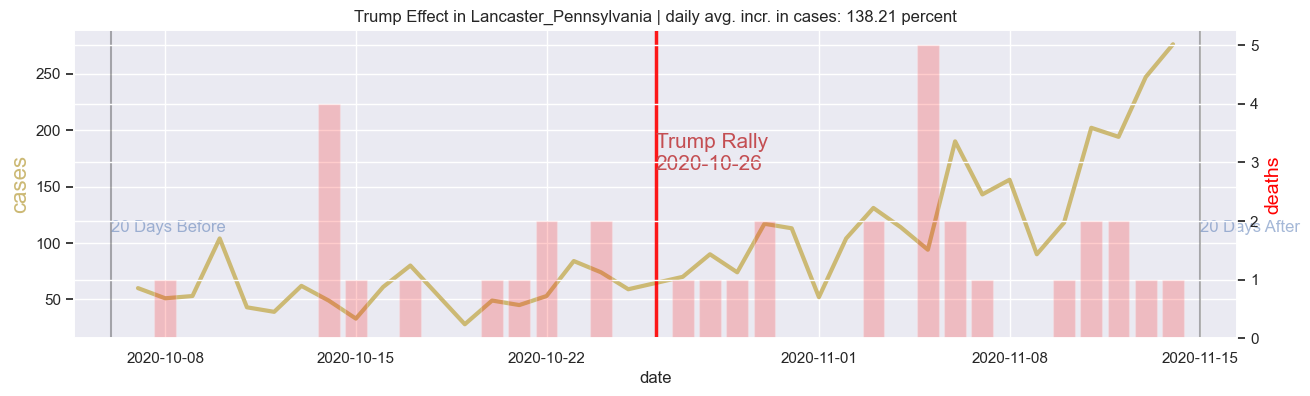

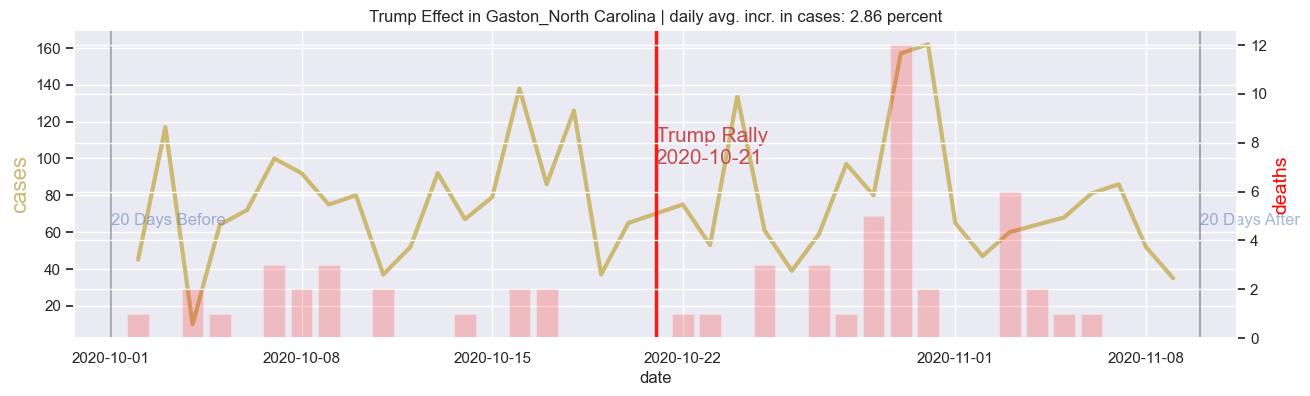

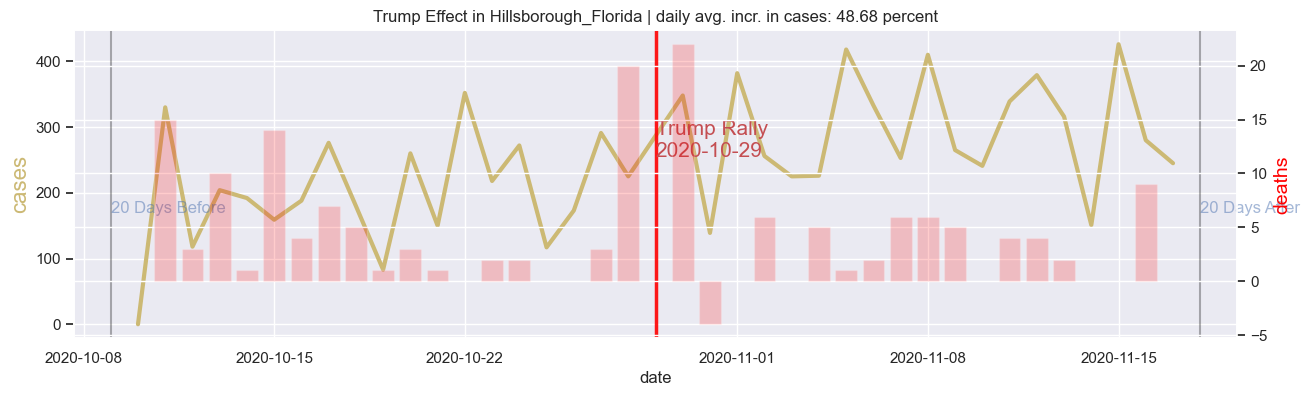

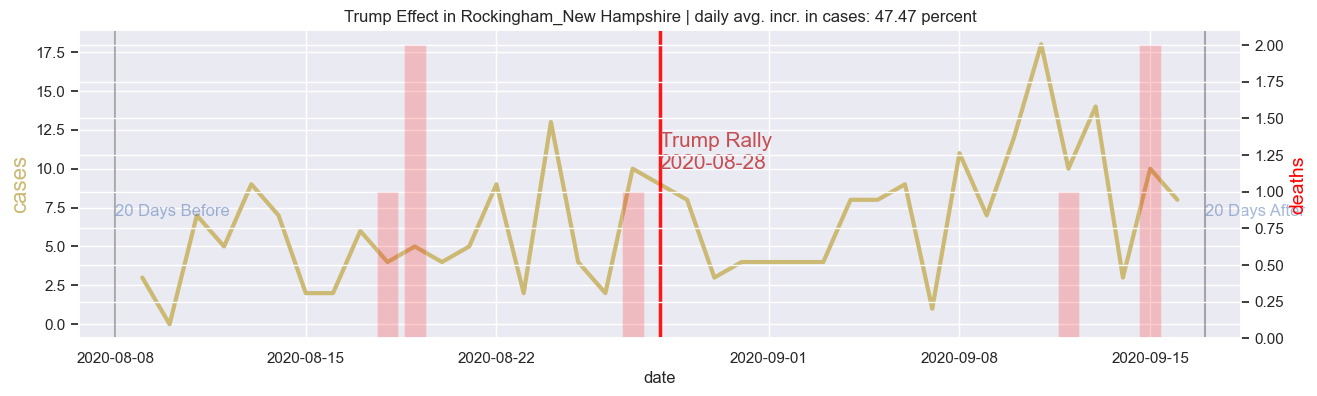

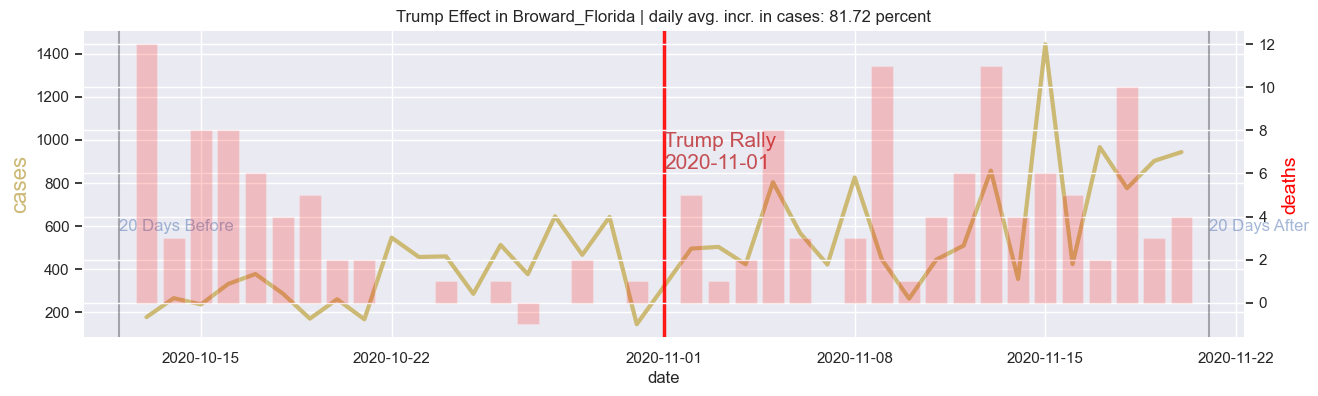

In [18]:
trump_rally_effect(7,plot=True);
trump_rally_effect(8,plot=True);
trump_rally_effect(5,plot=True);
trump_rally_effect(20,plot=True);
trump_rally_effect(19,plot=True);
trump_rally_effect(18,plot=True);
trump_rally_effect(1,plot=True);
trump_rally_effect(17,plot=True);
trump_rally_effect(14,plot=True);
trump_rally_effect(0,plot=True);

#### US by County | % change in cases over period of rally

In [19]:
def plot_intra_state_distribution(df):
    plt.figure(figsize=(15, 4))
    plt.xticks(rotation=90)
    plt.xlabel('daily pct increase in cases')
    lb_lf=df.sort_values('stat')
    barlist=plt.bar(lb_lf.county_state_x,lb_lf.stat.replace([np.inf, -np.inf], np.nan))
    barlist[-8].set_color('r')

In [20]:
def show_map(df,stat,center,hov='county_state',loc=None):
    
    """
    stat: name of column with stat
    center: list of lat lon of rally to center map on
    hov: column name of msg to display in hover tooltip
    loc: name of rally by county_state
    """
    
    fig = px.choropleth(df, geojson=counties, locations='fips', color=stat,
                               color_continuous_scale="Blues",
                               range_color=(0, max(df[stat])),
                               scope='usa',
                               hover_name=hov,
                               labels={stat:'mean change in new cases'},
                               center={'lat': center[0] , 'lon': center[1]}
                              )
    fig.update_geos(fitbounds="locations", visible=False)
                        
    fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
#    ax.annotate(‘Source: London Datastore, 2014’,xy=(0.1, .08),  
 #   xycoords='figure fraction', horizontalalignment='left', verticalalignment='top', fontsize=12, color='#555555')
    fig.show()

In [21]:
def centroid_from_coord(coord):
    """Compute centroid from county_coordinates coord field.
    coord is either [lon, lat] (Polygon) or [[lon,lat], ...] (MultiPolygon)."""
    if isinstance(coord[0], (int, float)):
        # Single point [lon, lat]
        return coord[1], coord[0]  # lat, lon
    else:
        # List of [lon, lat] pairs
        return np.mean([c[1] for c in coord]), np.mean([c[0] for c in coord])

def show_counties(df,idx):
    state=tmp.county_state[idx].split('_')[1]
    print(tmp.county_state[idx])
    look_forward=filter_time(df,tmp.date[idx],20,True)
    look_backward=filter_time(df,tmp.date[idx],20,False)
    lf=look_forward.query('state == "{}"'.format(state)).groupby(['county_state','fips'])[['new_cases']].mean().reset_index()
    lb=look_backward.query('state == "{}"'.format(state)).groupby(['county_state','fips'])[['new_cases']].mean().reset_index()
    lb_lf=lb.merge(lf, on='fips').merge(county_coordinates, on='fips')
    lb_lf['stat']=((lb_lf.new_cases_y-lb_lf.new_cases_x)/lb_lf.new_cases_x)*100
    # Compute center from the rally county's polygon coordinates
    rally_fips = lb_lf.query('county_state_x == "{}"'.format(tmp.loc[idx].county_state))
    if len(rally_fips) > 0:
        center = list(centroid_from_coord(rally_fips['coord'].values[0]))
    else:
        all_coords = []
        for coord_list in lb_lf['coord']:
            if isinstance(coord_list[0], (int, float)):
                all_coords.append(coord_list)
            else:
                all_coords.extend(coord_list)
        center = [np.mean([c[1] if isinstance(c, list) else c for c in all_coords]),
                  np.mean([c[0] if isinstance(c, list) else 0 for c in all_coords])]
    show_map(lb_lf,center=center,stat='stat',hov='county_state_x')
    plot_intra_state_distribution(lb_lf)

#### Beltrami Minnesota

In [22]:
# compare after-before
look_forward=filter_time(df,tmp.date[7],20,True)
look_backward=filter_time(df,tmp.date[7],20,False)
lf=look_forward.query('state == "Minnesota"').groupby(['county_state','fips'])[['new_cases']].mean().reset_index()
lb=look_backward.query('state == "Minnesota"').groupby(['county_state','fips'])[['new_cases']].mean().reset_index()
lb_lf=lb.merge(lf, on='fips').merge(county_coordinates, on='fips')
lb_lf['stat']=((lb_lf.new_cases_y-lb_lf.new_cases_x)/lb_lf.new_cases_x)*100
# Compute center from the rally county's polygon coordinates
rally_fips = lb_lf.query('county_state_x == "{}"'.format(tmp.loc[7].county_state))
if len(rally_fips) > 0:
    center = list(centroid_from_coord(rally_fips['coord'].values[0]))
else:
    all_coords = []
    for coord_list in lb_lf['coord']:
        if isinstance(coord_list[0], (int, float)):
            all_coords.append(coord_list)
        else:
            all_coords.extend(coord_list)
    center = [np.mean([c[1] if isinstance(c, list) else c for c in all_coords]),
              np.mean([c[0] if isinstance(c, list) else 0 for c in all_coords])]
show_map(lb_lf,center=center,stat='stat',hov='county_state_x',loc=tmp.county_state[7].split('_')[0])

#### Marathon Wisconsin

In [23]:
show_counties(df,8)

#### Fulton Ohio

In [24]:
show_counties(df,5)

#### Lackawanna Pennsylvania

In [25]:
show_counties(df,15)

#### Creek Oklahoma

In [26]:
show_counties(df,20)

---
#### Conclusion

Of the 21 Trump campaign rallies held after March 13, 2020, **17 out of 21 (81%)** were followed by an increase in mean daily COVID-19 cases in the host county over the subsequent 20 days, compared to the 20 days prior.

**Summary statistics (20-day window comparison):**

| Metric | Value |
|--------|-------|
| Rallies with post-rally case increase | 17 / 21 (81%) |
| Rallies with post-rally case decrease | 4 / 21 (19%) |
| Mean change in daily cases across all rally counties | +99.82% |
| Median change | +72.15% |
| Standard deviation | 115.18% |
| Largest increase | +370.45% (Beltrami County, MN — Sep 18, 2020) |
| Largest decrease | -36.92% (Saginaw County, MI — Sep 10, 2020) |
| National baseline mean change (state-level avg over period) | +50.54% |

The five counties with the highest post-rally increases were Beltrami, MN (+370%), Marathon, WI (+355%), Fulton, OH (+249%), Lackawanna, PA (+209%), and Creek, OK (+193%). These were generally smaller counties where even modest absolute increases in cases translated to large percentage swings. The four counties that saw decreases — Duval, FL; Clark, NV; Forsyth, NC; and Saginaw, MI — were larger metro areas where broader regional trends likely dominated any rally-specific signal.

The mean post-rally increase across rally counties (+99.82%) was roughly double the national baseline (+50.54%), though this comparison is crude: it does not control for regional wave timing, testing capacity changes, or the seasonal acceleration of cases during fall 2020.

**Limitations:** This is an observational analysis. Correlation is not causation. The 20-day window captures general trajectory shifts but cannot isolate rally attendance as the causal mechanism. Confounders include fall/winter seasonality, statewide policy changes, testing availability, and the nationwide case surge that coincided with the campaign period. A more rigorous analysis would require matched control counties, adjustment for secular trends, and accounting for rally attendance size relative to county population.